# Range regressor analysis

Loads saved outputs from `src/task2/xgboost_range_regressor.py` and regenerates the regression plots.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    if (PROJECT_ROOT.parent / "src").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
    else:
        raise FileNotFoundError("Could not locate project root containing src/")

RANGE_DIR = PROJECT_ROOT / "outputs" / "range_regressor"
ARTIFACT_DIR = RANGE_DIR / "artifacts"

plt.style.use("seaborn-v0_8-darkgrid")
RANGE_DIR

PosixPath('/home/keyreii/Documents/Data Analytics Mini Project/outputs/range_regressor')

In [2]:
metrics_df = pd.read_csv(RANGE_DIR / "xgb_regression_model_comparison.csv")
y_true_p1 = np.load(ARTIFACT_DIR / "y_true_p1.npy")
y_pred_p1 = np.load(ARTIFACT_DIR / "y_pred_p1.npy")
y_true_p2 = np.load(ARTIFACT_DIR / "y_true_p2.npy")
y_pred_p2 = np.load(ARTIFACT_DIR / "y_pred_p2.npy")
feature_importance_p1 = pd.read_csv(ARTIFACT_DIR / "feature_importance_p1.csv")
feature_importance_p2 = pd.read_csv(ARTIFACT_DIR / "feature_importance_p2.csv")

display(metrics_df)
display(feature_importance_p1.head())

,model,model_key,path,rmse,mae,r2,train_seconds,predict_seconds,cv_used,cv_splits,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,XGBoost,xgb,Path 1,1.174394,0.895827,0.748914,19.787955,0.030019,True,5,1.203948,0.021849,0.919997,0.009706,0.739482,0.008256
1,XGBoost,xgb,Path 2,1.187806,0.906362,0.792490,22.582889,0.025851,True,5,1.226819,0.021936,0.937290,0.010322,0.780008,0.008492


,Feature,Importance
0,PREAM_LEN,0.474239
1,noise_ratio,0.095535
2,RXPACC,0.057775
3,CIR_num_peaks,0.036076
4,CIR_PWR,0.015542


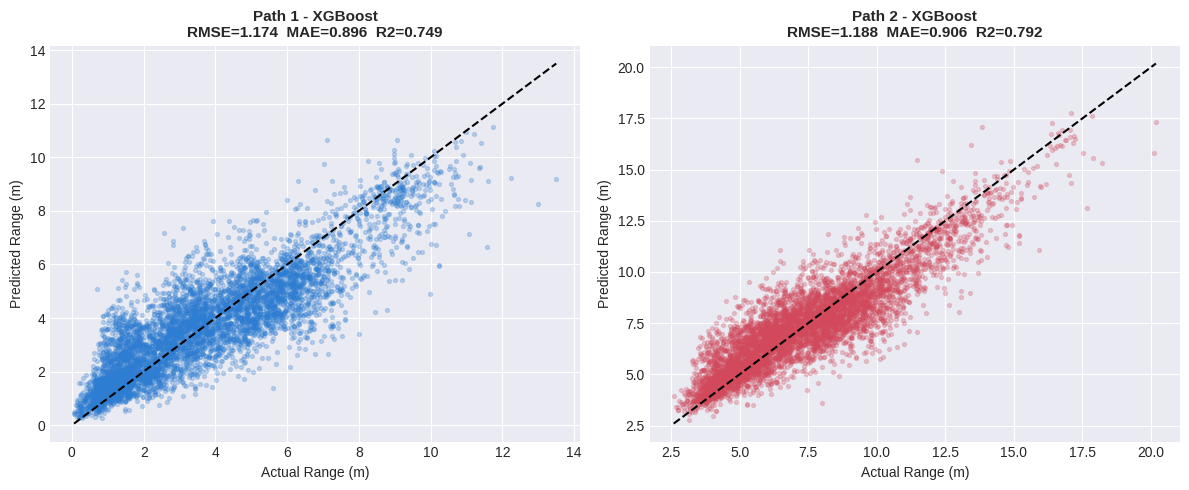

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)

ax = axes[0, 0]
ax.scatter(y_true_p1, y_pred_p1, alpha=0.25, s=8, color="#2d7dd2")
lims = [min(y_true_p1.min(), y_pred_p1.min()), max(y_true_p1.max(), y_pred_p1.max())]
ax.plot(lims, lims, "k--", linewidth=1.5)
row = metrics_df.loc[metrics_df["path"] == "Path 1"].iloc[0]
ax.set_xlabel("Actual Range (m)")
ax.set_ylabel("Predicted Range (m)")
ax.set_title(f"Path 1 - XGBoost\nRMSE={row['rmse']:.3f}  MAE={row['mae']:.3f}  R2={row['r2']:.3f}", fontsize=11, fontweight="bold")

ax = axes[0, 1]
ax.scatter(y_true_p2, y_pred_p2, alpha=0.25, s=8, color="#d1495b")
lims = [min(y_true_p2.min(), y_pred_p2.min()), max(y_true_p2.max(), y_pred_p2.max())]
ax.plot(lims, lims, "k--", linewidth=1.5)
row = metrics_df.loc[metrics_df["path"] == "Path 2"].iloc[0]
ax.set_xlabel("Actual Range (m)")
ax.set_ylabel("Predicted Range (m)")
ax.set_title(f"Path 2 - XGBoost\nRMSE={row['rmse']:.3f}  MAE={row['mae']:.3f}  R2={row['r2']:.3f}", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(RANGE_DIR / "xgb_range_estimation_results.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

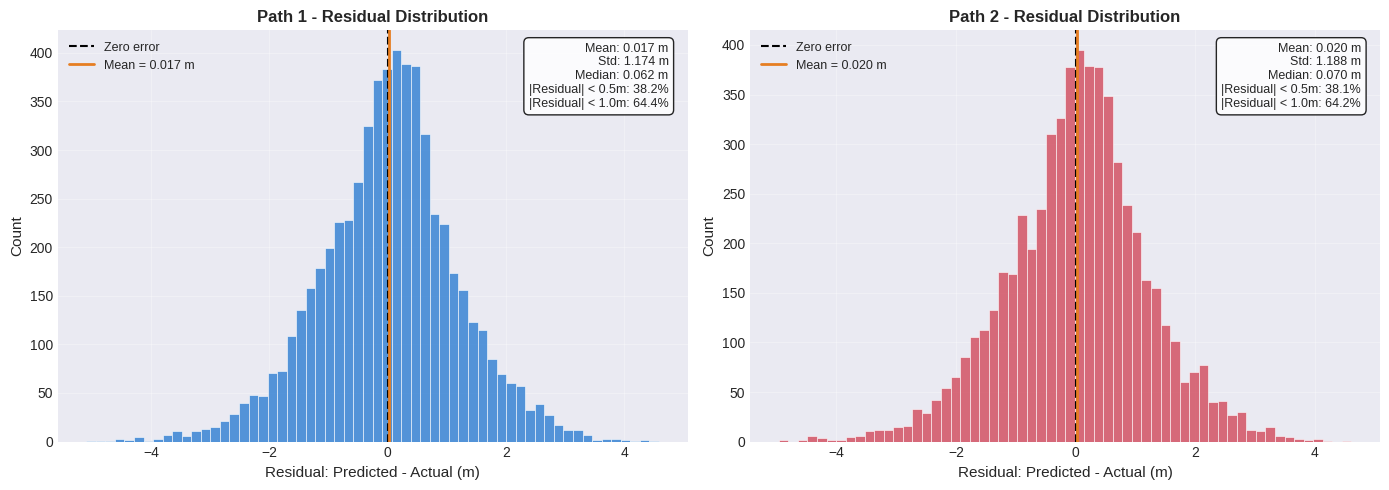

In [4]:
# Residual distribution — shows where errors concentrate
residuals_p1 = y_pred_p1 - y_true_p1
residuals_p2 = y_pred_p2 - y_true_p2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, residuals, path_label, color in [
    (axes[0], residuals_p1, "Path 1", "#2d7dd2"),
    (axes[1], residuals_p2, "Path 2", "#d1495b"),
]:
    ax.hist(residuals, bins=60, color=color, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.axvline(x=0, color="black", linestyle="--", linewidth=1.5, label="Zero error")
    ax.axvline(x=np.mean(residuals), color="#e67e22", linestyle="-", linewidth=2,
               label=f"Mean = {np.mean(residuals):.3f} m")
    ax.set_xlabel("Residual: Predicted - Actual (m)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"{path_label} - Residual Distribution", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Add stats text box
    stats_text = (
        f"Mean: {np.mean(residuals):.3f} m\n"
        f"Std: {np.std(residuals):.3f} m\n"
        f"Median: {np.median(residuals):.3f} m\n"
        f"|Residual| < 0.5m: {(np.abs(residuals) < 0.5).mean() * 100:.1f}%\n"
        f"|Residual| < 1.0m: {(np.abs(residuals) < 1.0).mean() * 100:.1f}%"
    )
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment="top", horizontalalignment="right",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85))

plt.tight_layout()
plt.savefig(RANGE_DIR / "xgb_residual_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

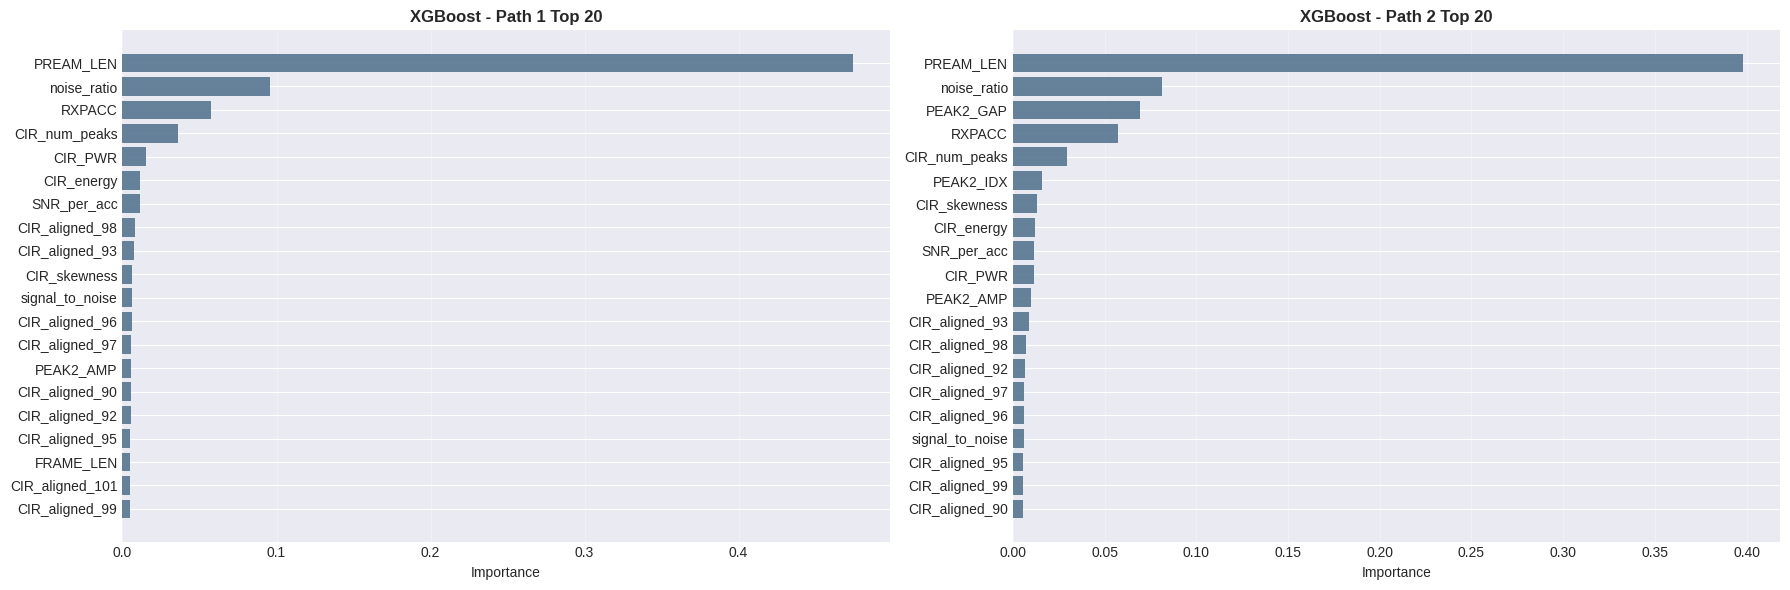

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), squeeze=False)
top_n = 20
for ax, path_label, df in [
    (axes[0, 0], 'Path 1', feature_importance_p1),
    (axes[0, 1], 'Path 2', feature_importance_p2),
]:
    top_df = df.head(top_n).iloc[::-1]
    ax.barh(top_df['Feature'], top_df['Importance'], color='#577590', alpha=0.9)
    ax.set_xlabel('Importance')
    ax.set_title(f'XGBoost - {path_label} Top {top_n}', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(RANGE_DIR / "xgb_regressor_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()